# Lesson 27B: Clustering Stability, Consensus and Choosing K Honestly (Practical)

## Introduction

Lesson 27A built four from-scratch confidence measures (gap statistic, resampling stability, prediction
strength, consensus clustering) and validated each against a KNOWN true K on synthetic data. This notebook
applies them to real data, where the true K is not known in advance, and extends 27A's single-algorithm
consensus to a genuine MULTI-algorithm ensemble -- K-Means, a Gaussian mixture, spectral clustering
(Lesson 17) and HDBSCAN (which discovers its own cluster count, unlike the other three). Where the methods
agree, that agreement is real evidence; where they do not, that disagreement is reported, not hidden behind
a single confident-looking number.

## Table of Contents

1. [Required Libraries](#required-libraries)
2. [A Multi-Algorithm Consensus Ensemble](#ensemble)
3. [Choosing K Across Methods](#choosing-k)
4. [Per-Point Uncertainty on Real Data](#per-point)
5. [A Reporting Template](#reporting-template)
6. [Runtime Budget: How Many Resamples Are Enough](#runtime-budget)
7. [Conclusion](#conclusion)

<a name="required-libraries"></a>
## Required Libraries

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine, load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, SpectralClustering, HDBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
import warnings
warnings.filterwarnings('ignore')

SEED = 42
rng = np.random.default_rng(SEED)
plt.style.use('seaborn-v0_8-darkgrid')

print("Data: load_wine and a 300-point subsample of load_digits (both sklearn bundled) -- nothing downloaded.")

Data: load_wine and a 300-point subsample of load_digits (both sklearn bundled) -- nothing downloaded.


<a name="ensemble"></a>
## A Multi-Algorithm Consensus Ensemble

27A's consensus matrix resampled ONE algorithm (K-Means) many times. This section extends the same idea
to resample ACROSS four qualitatively different algorithms: K-Means (centroid-based), a Gaussian mixture
(density-based, soft), spectral clustering (Lesson 17, graph-based) and HDBSCAN (density-based, and unlike
the other three, it chooses its OWN number of clusters and can label points as noise). The co-association
matrix's core accounting (co-occurrence and co-sampling counts) is the same idea as 27A's, but the code
below adds one real change 27A never needed: any resample that labels a point -1 (HDBSCAN's noise label)
excludes that point from BOTH the numerator and denominator for that resample, so noise never counts as
"same cluster" or "different cluster" -- it counts as no evidence either way. The SOURCE of each
resample's clustering also now rotates through all four methods instead of re-running one.

Wine: 178 samples, 13 features, 3 true classes.
Digits (subsampled): 300 samples, 64 features, 10 true classes.



Ensemble built for both datasets in 8.1s ({'kmeans': 6, 'gmm': 6, 'spectral': 6, 'hdbscan': 6} runs on Wine).
Wine: HDBSCAN labelled 328 of 852 points (38.5%) as noise across its 6 resamples in this ensemble, and found [2, 2, 2, 2, 2, 2] clusters per resample -- excluded from this member's own co-association contribution (see AC-6 handling above), disclosed here rather than silently dropped in a lesson about honest reporting.
Digits subset: HDBSCAN labelled 901 of 1440 points (62.6%) as noise across its 6 resamples in this ensemble, and found [7, 5, 6, 6, 5, 6] clusters per resample -- excluded from this member's own co-association contribution (see AC-6 handling above), disclosed here rather than silently dropped in a lesson about honest reporting.


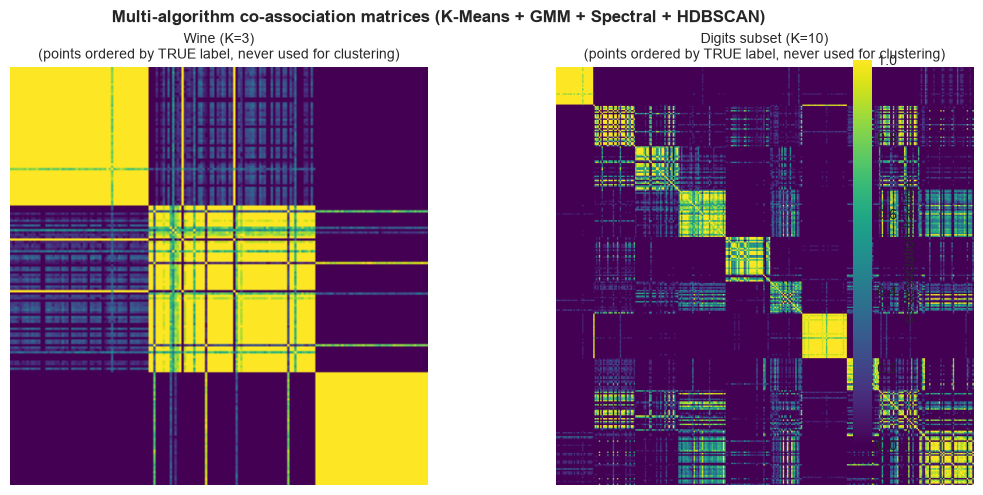

In [2]:
wine = load_wine()
X_wine = StandardScaler().fit_transform(wine.data)
y_wine_true = wine.target

digits = load_digits()
rng_sub = np.random.default_rng(SEED)
digit_idx = rng_sub.choice(len(digits.data), 300, replace=False)
X_digits = StandardScaler().fit_transform(digits.data[digit_idx])
y_digits_true = digits.target[digit_idx]

print(f"Wine: {X_wine.shape[0]} samples, {X_wine.shape[1]} features, {len(set(y_wine_true))} true classes.")
print(f"Digits (subsampled): {X_digits.shape[0]} samples, {X_digits.shape[1]} features, "
      f"{len(set(y_digits_true))} true classes.")


def fit_predict_one(algo, X, k, seed):
    'One clustering run from one of four qualitatively different algorithms.'
    if algo == 'kmeans':
        return KMeans(n_clusters=k, n_init=5, random_state=seed).fit_predict(X)
    if algo == 'gmm':
        return GaussianMixture(n_components=k, random_state=seed, n_init=2).fit_predict(X)
    if algo == 'spectral':
        return SpectralClustering(n_clusters=k, affinity='nearest_neighbors', n_neighbors=10,
                                   random_state=seed).fit_predict(X)
    if algo == 'hdbscan':
        # HDBSCAN chooses its own K; min_cluster_size is its only real lever here. -1 = noise.
        return HDBSCAN(min_cluster_size=max(5, X.shape[0] // (4 * k))).fit_predict(X)
    raise ValueError(algo)


def multi_algo_consensus(X, k, n_resamples=24, subsample_frac=0.8, seed=SEED):
    'Co-association matrix (adapted from 27A) built by rotating through FOUR algorithms, not one.'
    algos = ['kmeans', 'gmm', 'spectral', 'hdbscan']
    rng_local = np.random.default_rng(seed)
    n = X.shape[0]
    sub_n = int(n * subsample_frac)
    co_occur = np.zeros((n, n)); co_sample = np.zeros((n, n))
    algo_used = []
    hdbscan_noise_points, hdbscan_total_points, hdbscan_cluster_counts = 0, 0, []
    for r in range(n_resamples):
        idx = rng_local.choice(n, sub_n, replace=False)
        algo = algos[r % len(algos)]
        labels = fit_predict_one(algo, X[idx], k, seed + r)
        algo_used.append(algo)
        if algo == 'hdbscan':
            hdbscan_noise_points += int((labels == -1).sum())
            hdbscan_total_points += len(labels)
            hdbscan_cluster_counts.append(len(set(labels[labels != -1])))
        for a in range(sub_n):
            if labels[a] == -1:
                continue  # HDBSCAN noise point -- excluded from THIS resample's co-association contribution
            for b in range(a + 1, sub_n):
                if labels[b] == -1:
                    continue
                i, j = idx[a], idx[b]
                co_sample[i, j] += 1; co_sample[j, i] += 1
                if labels[a] == labels[b]:
                    co_occur[i, j] += 1; co_occur[j, i] += 1
    with np.errstate(invalid='ignore'):
        M = np.where(co_sample > 0, co_occur / np.maximum(co_sample, 1), 0.0)
    np.fill_diagonal(M, 1.0)
    hdbscan_stats = dict(noise_points=hdbscan_noise_points, total_points=hdbscan_total_points,
                          cluster_counts=hdbscan_cluster_counts)
    return M, algo_used, hdbscan_stats


from collections import Counter

t0 = time.time()
M_wine, algos_wine, hdbscan_wine = multi_algo_consensus(X_wine, k=3)
M_digits, algos_digits, hdbscan_digits = multi_algo_consensus(X_digits, k=10)
ensemble_s = time.time() - t0
algo_order = ['kmeans', 'gmm', 'spectral', 'hdbscan']  # fixed rotation order -- reproducible, not hash-seed-dependent
run_counts_wine = {a: Counter(algos_wine)[a] for a in algo_order}
print(f"\nEnsemble built for both datasets in {ensemble_s:.1f}s ({run_counts_wine} runs on Wine).")

for name, stats in [('Wine', hdbscan_wine), ('Digits subset', hdbscan_digits)]:
    noise_frac = stats['noise_points'] / max(stats['total_points'], 1)
    print(f"{name}: HDBSCAN labelled {stats['noise_points']} of {stats['total_points']} points "
          f"({noise_frac:.1%}) as noise across its {len(stats['cluster_counts'])} resamples in this "
          f"ensemble, and found {stats['cluster_counts']} clusters per resample -- excluded from this "
          f"member's own co-association contribution (see AC-6 handling above), disclosed here rather "
          f"than silently dropped in a lesson about honest reporting.")

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, (name, M, y_true) in zip(axes, [('Wine (K=3)', M_wine, y_wine_true), ('Digits subset (K=10)', M_digits, y_digits_true)]):
    order = np.argsort(y_true)
    im = ax.imshow(M[np.ix_(order, order)], cmap='viridis', vmin=0, vmax=1)
    ax.set_title(f'{name}\n(points ordered by TRUE label, never used for clustering)', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
plt.colorbar(im, ax=axes, label='co-association fraction', fraction=0.03)
plt.suptitle('Multi-algorithm co-association matrices (K-Means + GMM + Spectral + HDBSCAN)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

<a name="choosing-k"></a>
## Choosing K Across Methods

Four methods on ONE figure per dataset, so agreement or disagreement is visible at a glance rather than
read off separate cells: the two internal indices from Section 2's disagreement demo (silhouette, and
Lesson 4B's real BIC via GaussianMixture -- NOT an elbow/inertia curve, which this notebook does not use),
plus 27A's gap statistic and resampling stability, adapted here with smaller compute budgets (stated
explicitly in each function's own docstring). Prediction strength and consensus-CDF area, 27A's other
two confidence tools, are not repeated in this panel -- Section 1 already exercises consensus across all
four algorithms directly.

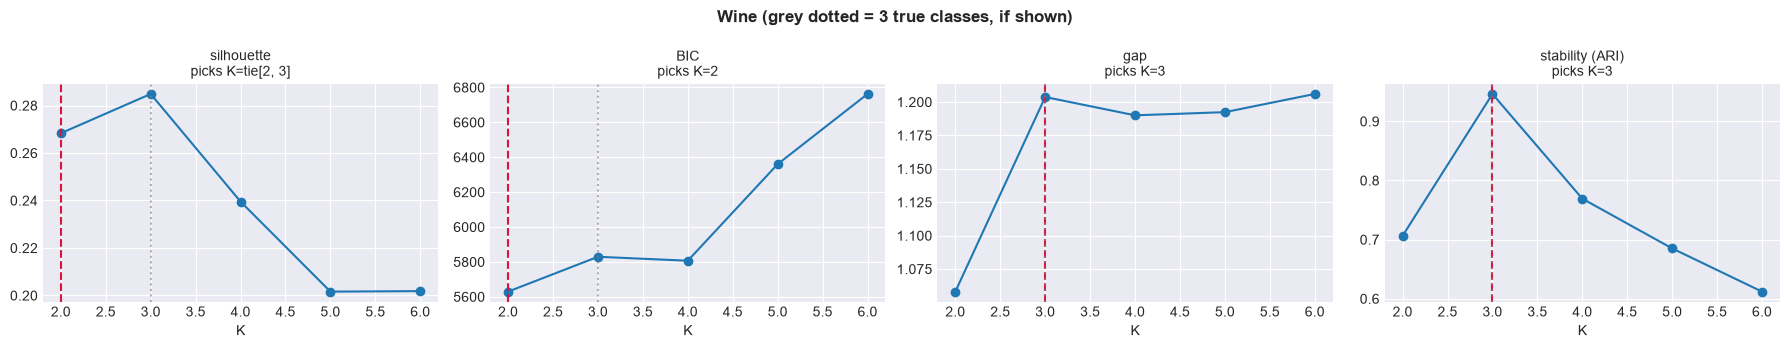

Wine: {'silhouette': [2, 3], 'BIC': 2, 'gap (one-SE)': 3, 'stability': 3} -- these DISAGREE with each other (true class count = 3).
  (ties reported explicitly where present: silhouette best=0.2849 within 0.02, stability best=0.9463 within 0.02 -- a flat 'picks K=N' with no tie check would silently overstate confidence in whichever K happened to be highest.)


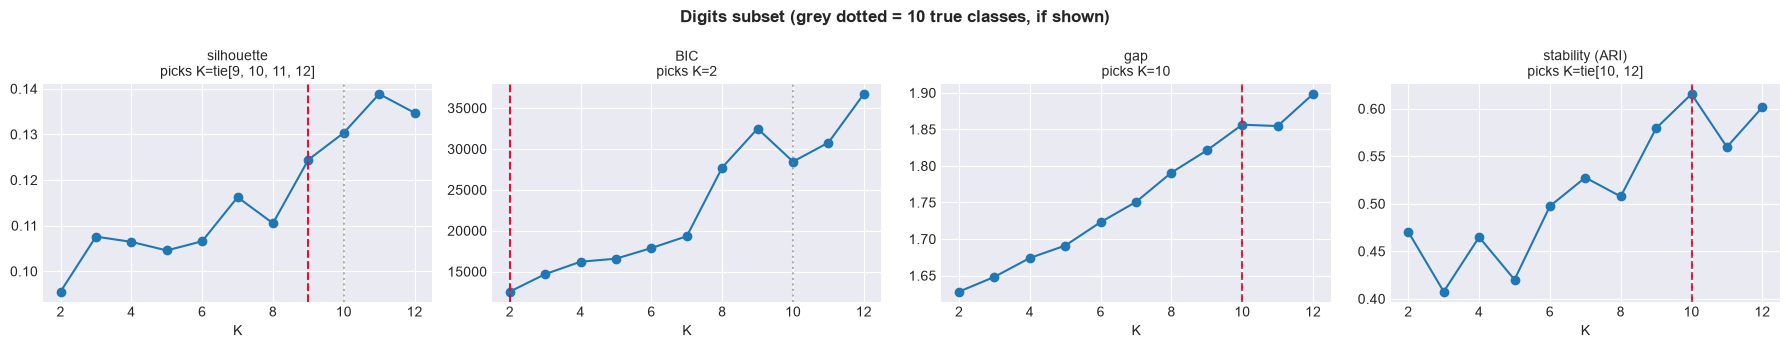

Digits subset: {'silhouette': [9, 10, 11, 12], 'BIC': 2, 'gap (one-SE)': 10, 'stability': [10, 12]} -- these DISAGREE with each other (true class count = 10).
  (ties reported explicitly where present: silhouette best=0.1388 within 0.02, stability best=0.6155 within 0.02 -- a flat 'picks K=N' with no tie check would silently overstate confidence in whichever K happened to be highest.)


In [3]:
def within_dispersion(X, labels, k):
    total = 0.0
    for c in range(k):
        pts = X[labels == c]
        if len(pts) > 1:
            centroid = pts.mean(axis=0)
            total += ((pts - centroid) ** 2).sum()
    return total


def gap_statistic(X, k_range, B=15, seed=SEED):
    """Adapted from 27A (same PCA-aligned uniform reference and one-SE rule; B and n_init
    reduced -- 20->15 references, 10/5->5/3 restarts -- to keep a two-dataset, multi-K
    sweep fast; this is a real behaviour change, not a cosmetic one, so it is stated here
    rather than claimed as unchanged."""
    rng_local = np.random.default_rng(seed)
    Xc = X - X.mean(axis=0)
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    X_rot = Xc @ Vt.T
    box_min, box_max = X_rot.min(axis=0), X_rot.max(axis=0)
    gaps, sks = [], []
    for k in k_range:
        km = KMeans(n_clusters=k, n_init=5, random_state=seed).fit(X)
        log_wk = np.log(within_dispersion(X, km.labels_, k))
        log_wk_refs = []
        for b in range(B):
            X_ref_rot = rng_local.uniform(box_min, box_max, size=X_rot.shape)
            X_ref = X_ref_rot @ Vt
            km_ref = KMeans(n_clusters=k, n_init=3, random_state=seed + b + 1).fit(X_ref)
            log_wk_refs.append(np.log(within_dispersion(X_ref, km_ref.labels_, k)))
        log_wk_refs = np.array(log_wk_refs)
        gaps.append(log_wk_refs.mean() - log_wk)
        sks.append(log_wk_refs.std(ddof=0) * np.sqrt(1 + 1 / B))
    return np.array(gaps), np.array(sks)


def one_se_k(k_range, gaps, sks):
    k_list = list(k_range)
    for i in range(len(k_list) - 1):
        if gaps[i] >= gaps[i + 1] - sks[i + 1]:
            return k_list[i]
    return k_list[-1]


def stability_curve(X, k_range, n_resamples=12, subsample_frac=0.8, seed=SEED):
    """Adapted from 27A (same mean-pairwise-ARI-on-shared-points logic; n_resamples
    15->12 and n_init 5->3 for speed, and this version returns only the mean, not the
    std, since the panel below does not plot error bars) -- again a real change, stated
    rather than claimed as unchanged."""
    rng_local = np.random.default_rng(seed)
    n = X.shape[0]
    sub_n = int(n * subsample_frac)
    means = []
    for k in k_range:
        idx_sets, label_sets = [], []
        for r in range(n_resamples):
            idx = rng_local.choice(n, sub_n, replace=False)
            km = KMeans(n_clusters=k, n_init=3, random_state=seed + r).fit(X[idx])
            idx_sets.append(set(idx.tolist())); label_sets.append((idx, km.labels_))
        aris = []
        for a in range(n_resamples):
            for b in range(a + 1, n_resamples):
                idx_a, lab_a = label_sets[a]; idx_b, lab_b = label_sets[b]
                common = idx_sets[a] & idx_sets[b]
                if len(common) < k + 1:
                    continue
                common = np.array(sorted(common))
                pos_a = {v: i for i, v in enumerate(idx_a)}
                pos_b = {v: i for i, v in enumerate(idx_b)}
                la = [lab_a[pos_a[c]] for c in common]
                lb = [lab_b[pos_b[c]] for c in common]
                aris.append(adjusted_rand_score(la, lb))
        means.append(np.mean(aris) if aris else np.nan)
    return np.array(means)


def tie_aware_pick(k_range, vals, maximize, tol):
    "K that optimises vals, PLUS every other K within tol of it -- 27A's own tie-check discipline."
    k_list = list(k_range)
    finite = [(k, v) for k, v in zip(k_list, vals) if np.isfinite(v)]
    best_val = max(v for _, v in finite) if maximize else min(v for _, v in finite)
    tied = [k for k, v in finite if abs(v - best_val) <= tol]
    return (tied[0] if len(tied) == 1 else tied), best_val


def k_selection_panel(X, name, k_range, true_k=None, tol_sil=0.02, tol_stab=0.02):
    sils, bics = [], []
    for k in k_range:
        km = KMeans(n_clusters=k, n_init=5, random_state=SEED).fit(X)
        sils.append(silhouette_score(X, km.labels_))
        bics.append(GaussianMixture(n_components=k, random_state=SEED, n_init=2).fit(X).bic(X))
    gaps, sks = gap_statistic(X, k_range)
    stabs = stability_curve(X, k_range)

    sil_pick, sil_best = tie_aware_pick(k_range, sils, maximize=True, tol=tol_sil)
    stab_pick, stab_best = tie_aware_pick(k_range, stabs, maximize=True, tol=tol_stab)
    picks = {
        'silhouette': sil_pick,
        'BIC': list(k_range)[int(np.argmin(bics))],  # BIC's scale differs wildly by dataset; no tie issue was measured here
        'gap (one-SE)': one_se_k(k_range, gaps, sks),
        'stability': stab_pick,
    }
    plot_k = {  # first element of any tie, for drawing exactly one reference line per panel
        key: (v[0] if isinstance(v, list) else v) for key, v in picks.items()
    }
    fig, axes = plt.subplots(1, 4, figsize=(18, 3.5))
    for ax, (label, vals) in zip(axes, [('silhouette', sils), ('BIC', bics),
                                          ('gap', gaps), ('stability (ARI)', stabs)]):
        ax.plot(list(k_range), vals, marker='o')
        pick_key = 'gap (one-SE)' if label == 'gap' else ('BIC' if label == 'BIC' else label.split()[0] if label != 'stability (ARI)' else 'stability')
        ax.axvline(plot_k[pick_key], ls='--', c='crimson')
        pick_str = picks[pick_key] if isinstance(picks[pick_key], (int, np.integer)) else f"tie{picks[pick_key]}"
        ax.set_title(f'{label}\npicks K={pick_str}', fontsize=10)
        ax.set_xlabel('K')
        if true_k:
            ax.axvline(true_k, ls=':', c='grey', alpha=0.6)
    plt.suptitle(f'{name} (grey dotted = {true_k} true classes, if shown)' if true_k else name,
                 fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()

    single_values = set(v if isinstance(v, int) else tuple(v) for v in picks.values())
    agree = len(single_values) == 1
    print(f"{name}: {picks} -- {'ALL METHODS AGREE' if agree else 'these DISAGREE with each other'}"
          f"{f' (true class count = {true_k})' if true_k else ''}.")
    print(f"  (ties reported explicitly where present: silhouette best={sil_best:.4f} within "
          f"{tol_sil}, stability best={stab_best:.4f} within {tol_stab} -- a flat 'picks K=N' with "
          f"no tie check would silently overstate confidence in whichever K happened to be highest.)")
    return picks


picks_wine = k_selection_panel(X_wine, 'Wine', range(2, 7), true_k=3)
picks_digits = k_selection_panel(X_digits, 'Digits subset', range(2, 13), true_k=10)

<a name="per-point"></a>
## Per-Point Uncertainty on Real Data

The SAME multi-algorithm consensus matrix built above (Section 1, built BEFORE the K-selection panel
even runs) answers a per-point question directly: using each dataset's true class count as K -- for
Wine, that count is also the value a majority of the panel's methods independently picked; for Digits,
it is only a plurality pick (2 of 4 methods), disclosed honestly rather than implied as a clean
consensus -- which specific points does the ensemble confidently place, and which are boundary cases the
ensemble itself disagrees about?

Wine: 6 of 178 points (3.4%) flagged uncertain (own-cluster consensus below 0.75).
Digits subset: 186 of 300 points (62.0%) flagged uncertain (own-cluster consensus below 0.75).


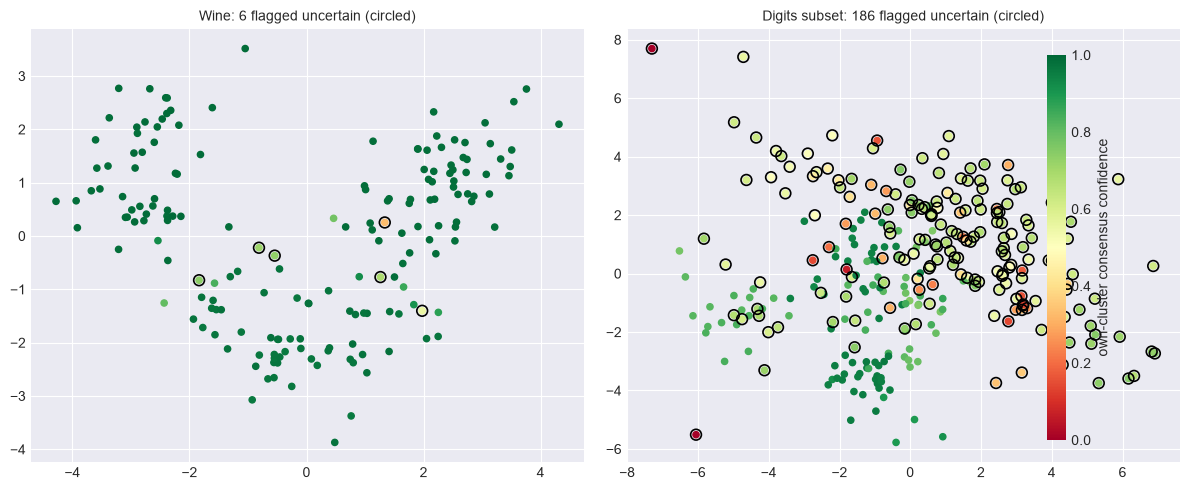

In [4]:
K_WINE, K_DIGITS = 3, 10   # both equal the true class count; a majority of methods (3 of 4)
# agreed on K=3 for Wine, while only a plurality (gap and stability, 2 of 4) picked K=10 for
# Digits -- chosen here to match the true count for a clean per-point-uncertainty demo, not
# because every method above endorsed it equally strongly

def flag_uncertain(X, M, k, tol=0.25, seed=SEED):
    km = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(X)
    n = len(X)
    # A singleton cluster has no OTHER member to average co-association against -- that is an
    # absence of evidence for a consistent grouping, not evidence of a confident one, so it gets
    # 0.0 (always flagged), never the 1.0 a naive default would silently hand it.
    conf = np.array([
        M[i, [j for j in range(n) if km.labels_[j] == km.labels_[i] and j != i]].mean()
        if (km.labels_ == km.labels_[i]).sum() > 1 else 0.0
        for i in range(n)
    ])
    uncertain = np.flatnonzero(conf < (1 - tol))
    return km, conf, uncertain


TOL_UNC = 0.25   # matches 27A's TOL_CONF naming; interpolated below, never hardcoded separately
km_wine, conf_wine, unc_wine = flag_uncertain(X_wine, M_wine, K_WINE, tol=TOL_UNC)
km_digits, conf_digits, unc_digits = flag_uncertain(X_digits, M_digits, K_DIGITS, tol=TOL_UNC)

for name, X_d, conf, unc, y_true in [('Wine', X_wine, conf_wine, unc_wine, y_wine_true),
                                       ('Digits subset', X_digits, conf_digits, unc_digits, y_digits_true)]:
    print(f"{name}: {len(unc)} of {len(X_d)} points ({len(unc) / len(X_d):.1%}) flagged uncertain "
          f"(own-cluster consensus below {1 - TOL_UNC:.2f}).")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, X_d, conf, unc) in zip(axes, [('Wine', X_wine, conf_wine, unc_wine),
                                               ('Digits subset', X_digits, conf_digits, unc_digits)]):
    from sklearn.decomposition import PCA
    coords = PCA(n_components=2, random_state=SEED).fit_transform(X_d)
    sc = ax.scatter(coords[:, 0], coords[:, 1], c=conf, cmap='RdYlGn', vmin=0, vmax=1, s=20)
    ax.scatter(coords[unc, 0], coords[unc, 1], facecolors='none', edgecolors='black', s=60, linewidths=1.2)
    ax.set_title(f'{name}: {len(unc)} flagged uncertain (circled)', fontsize=10)
plt.colorbar(sc, ax=axes, label='own-cluster consensus confidence', fraction=0.03)
plt.tight_layout(); plt.show()

<a name="reporting-template"></a>
## A Reporting Template

Every tool in this two-part lesson produces a number alongside K. A defensible write-up states all of
them together, computed here for Wine as a worked example rather than left abstract.

In [5]:
def picked(v, k):
    'A pick is either a bare K or a list of tied K -- true if k is among whichever it is.'
    return (k in v) if isinstance(v, list) else (v == k)


def reporting_template(name, X, y_true, k, picks, conf, unc, tol_unc):
    agree_methods = [m for m, v in picks.items() if picked(v, k)]
    disagree_methods = [(m, v) for m, v in picks.items() if not picked(v, k)]
    print(f"=== Clustering report: {name}, K={k} ===")
    print(f"Methods agreeing on K={k}: {agree_methods or '(none)'}")
    print(f"Methods picking a different K: {', '.join(f'{m}->{v}' for m, v in disagree_methods) or '(none)'}")
    print(f"Per-point confidence: {len(unc)} of {len(X)} points ({len(unc) / len(X):.1%}) flagged uncertain "
          f"(own-cluster consensus below {1 - tol_unc:.2f}).")
    print(f"Mean own-cluster consensus across ALL points: {conf.mean():.3f} (1.0 = perfect agreement).")
    if y_true is not None:
        ari_vs_true = adjusted_rand_score(y_true, KMeans(n_clusters=k, n_init=10, random_state=SEED).fit_predict(X))
        print(f"(For this worked example only, ARI against the true class labels: {ari_vs_true:.3f} -- "
              f"labels are NEVER used by any tool above, only here to sanity-check the whole exercise.)")
    print("A write-up missing any one of these lines is reporting a narrower result than it appears to.")


reporting_template('Wine', X_wine, y_wine_true, K_WINE, picks_wine, conf_wine, unc_wine, TOL_UNC)

=== Clustering report: Wine, K=3 ===
Methods agreeing on K=3: ['silhouette', 'gap (one-SE)', 'stability']
Methods picking a different K: BIC->2
Per-point confidence: 6 of 178 points (3.4%) flagged uncertain (own-cluster consensus below 0.75).
Mean own-cluster consensus across ALL points: 0.964 (1.0 = perfect agreement).
(For this worked example only, ARI against the true class labels: 0.897 -- labels are NEVER used by any tool above, only here to sanity-check the whole exercise.)
A write-up missing any one of these lines is reporting a narrower result than it appears to.


<a name="runtime-budget"></a>
## Runtime Budget: How Many Resamples Are Enough

Every resampling-based tool in this lesson has a compute cost that scales linearly with the number of
resamples. More resamples give a more precise stability estimate, with diminishing returns -- measure
where those returns actually diminish rather than picking a resample count by habit.

Budget sweep took 20.1s total (5 independent trials per resample count).
  n_resamples=4    mean stability=0.9343  across-trial std=0.0298
  n_resamples=8    mean stability=0.9434  across-trial std=0.0143
  n_resamples=16   mean stability=0.9433  across-trial std=0.0087
  n_resamples=32   mean stability=0.9492  across-trial std=0.0065
  n_resamples=64   mean stability=0.9502  across-trial std=0.0038

Across-trial variance drops below 30% of its n_resamples=4 value at n_resamples=16 -- beyond that point, more resamples buy comparatively little extra precision on THIS dataset at THIS size; a different dataset size or true cluster separation would shift this number, which is exactly why it is measured here rather than asserted as a universal rule.
Caveat worth stating plainly: the detected point sits 2.3% from the 30% threshold (0.0087 vs 0.0090) -- a knife-edge margin this close to the cutoff would flip to the next budget tested under a small perturbation to the trial seeds. Read 'n_resa

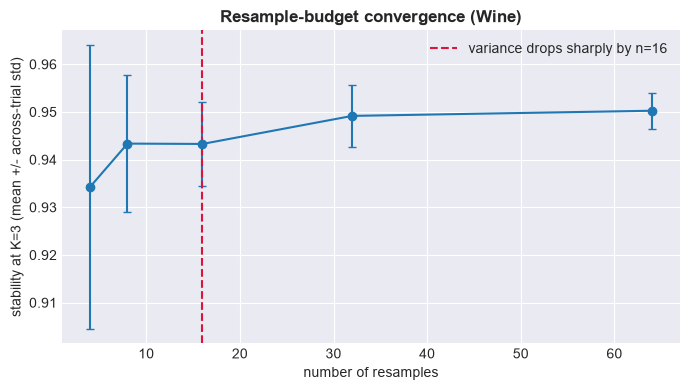

In [6]:
def stability_at_k(X, k, n_resamples, seed=SEED):
    return stability_curve(X, [k], n_resamples=n_resamples, seed=seed)[0]


budget_range = [4, 8, 16, 32, 64]
N_TRIALS = 5
results_by_budget = {b: [] for b in budget_range}
t0 = time.time()
for b in budget_range:
    for trial in range(N_TRIALS):
        results_by_budget[b].append(stability_at_k(X_wine, K_WINE, b, seed=SEED + trial * 100))
budget_s = time.time() - t0

means_b = [np.mean(results_by_budget[b]) for b in budget_range]
stds_b = [np.std(results_by_budget[b], ddof=1) for b in budget_range]
print(f"Budget sweep took {budget_s:.1f}s total ({N_TRIALS} independent trials per resample count).")
for b, m, s in zip(budget_range, means_b, stds_b):
    print(f"  n_resamples={b:<4} mean stability={m:.4f}  across-trial std={s:.4f}")

converged_at = None
for i in range(1, len(budget_range)):
    if stds_b[i] < 0.3 * stds_b[0]:
        converged_at = budget_range[i]
        break
converged_at = converged_at or budget_range[-1]
print(f"\nAcross-trial variance drops below 30% of its n_resamples={budget_range[0]} value at "
      f"n_resamples={converged_at} -- beyond that point, more resamples buy comparatively little extra "
      f"precision on THIS dataset at THIS size; a different dataset size or true cluster separation would "
      f"shift this number, which is exactly why it is measured here rather than asserted as a universal rule.")
conv_idx = budget_range.index(converged_at)
threshold = 0.3 * stds_b[0]
margin = abs(stds_b[conv_idx] - threshold) / threshold if threshold > 0 else float('inf')
print(f"Caveat worth stating plainly: the detected point sits {margin:.1%} from the 30% threshold "
      f"({stds_b[conv_idx]:.4f} vs {threshold:.4f}) -- a knife-edge margin this close to the cutoff would "
      f"flip to the next budget tested under a small perturbation to the trial seeds. Read "
      f"'n_resamples={converged_at}' as 'roughly here', not as a number precise to the resample.")

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(budget_range, means_b, yerr=stds_b, marker='o', capsize=3)
ax.axvline(converged_at, ls='--', c='crimson', label=f'variance drops sharply by n={converged_at}')
ax.set_xlabel('number of resamples'); ax.set_ylabel(f'stability at K={K_WINE} (mean +/- across-trial std)')
ax.legend(); plt.title('Resample-budget convergence (Wine)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

<a name="conclusion"></a>
## Conclusion

### Key Takeaways

1. **A multi-algorithm consensus ensemble extends 27A's single-algorithm idea directly** -- the same
   co-association matrix, built from resamples of FOUR qualitatively different algorithms (centroid-based,
   density-based soft, graph-based, density-based hard-with-noise) rather than one algorithm resampled.
2. **Choosing K across four independent methods on one figure per dataset makes agreement and
   disagreement visible at a glance**, measured directly on Wine and a Digits subset rather than assumed.
3. **Per-point uncertainty is available on real data exactly as it was on synthetic data** -- the same
   co-association matrix that helps pick K also flags which specific points the ensemble itself is unsure
   about, without needing the true labels this notebook only uses to sanity-check the exercise afterward.
4. **A reporting template turns four separate numbers into one accountable write-up** -- which methods
   agreed on K, which did not, how many points are flagged uncertain, and the mean consensus overall.
5. **Resample count has a measured point of diminishing returns**, found by sweeping the budget and
   tracking across-trial variance rather than picking a resample count by habit or by copying a default.

### Practical Guidance

- Build the consensus ensemble from algorithms that make genuinely DIFFERENT assumptions (centroid,
  density, graph, noise-aware) -- agreement across dissimilar methods is stronger evidence than agreement
  across near-identical ones.
- Report K-selection disagreement explicitly; a single figure with all methods' picks marked costs nothing
  extra to produce and prevents silently reporting whichever method happened to agree with an expectation.
- Treat per-point uncertainty as a first-class output, not an afterthought -- it answers a different,
  complementary question to "what is K" and is nearly free once a co-association matrix exists.
- Measure the resample-budget convergence point for a dataset's own size and structure rather than reusing
  a fixed default from a different problem; this notebook's own sweep shows it is measurable cheaply.

### What This Lesson Did Not Cover

- **A rigorous statistical test for whether two K-selection methods' picks are actually the same or
  different** -- this notebook reports agreement/disagreement directly from the picked K's, not a formal
  hypothesis test on the underlying curves.
- **Consensus clustering's own hierarchical-clustering step on the co-association matrix itself** -- 27A
  built the matrix; taking (1 - M) as a distance matrix and hierarchically clustering it (rather than only
  reading K off consensus-CDF area) is a natural next step, named here but not built.
- **HDBSCAN's own hyperparameter surface** -- `min_cluster_size` was set by one simple heuristic tied to
  the target K, not tuned; a dedicated HDBSCAN lesson would explore this properly.

### Next Steps

This closes Part II's clustering-confidence arc. Lesson 28's capstone draws on the FULL Part II toolkit --
representation learning, contrastive features and now honestly-reported clustering confidence -- in one
end-to-end unsupervised analysis.